# Sesión 8 — Clasificación en Machine Learning

## Objetivo del notebook

En este notebook vas a:

1. Entrenar modelos de clasificación con una base guiada: **Iris**.
2. Comparar cuatro clasificadores:
   - kNN
   - Árbol de decisión
   - Naive Bayes
   - SVM
3. Evaluar modelos con:
   - accuracy
   - matriz de confusión
   - precision, recall y F1-score
4. Resolver ejercicios autónomos con una base de datos de **Pokémon**.

## Idea clave

No existe un clasificador universalmente mejor.  
Cada modelo representa los datos de forma distinta.

## 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Parte 1 — Ejemplo guiado con Iris

La base `Iris` contiene mediciones de flores y una etiqueta de especie.

Variables:

- largo del sépalo
- ancho del sépalo
- largo del pétalo
- ancho del pétalo

Etiqueta:

- especie de flor

## 2. Cargar base Iris

In [2]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Explorar la base

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### Preguntas de reflexión

1. ¿Cuántas variables de entrada tiene la base?
    > 4
2. ¿Cuántas clases existen?
    > 3
3. ¿Este es un problema binario o multiclase?
    > Multiclase

## 4. Separar variables de entrada y salida

In [6]:
X = df.drop(columns=["species"])
y = df["species"]

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 5. Dividir datos en entrenamiento y prueba

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (112, 4)
Tamaño de prueba: (38, 4)


## 6. Escalar datos

Algunos clasificadores, como kNN y SVM, son sensibles a la escala porque dependen de distancias o márgenes.

Árboles de decisión y Naive Bayes no siempre necesitan escalamiento, pero aquí usaremos una versión escalada para mantener el flujo simple.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Parte 2 — Entrenar clasificadores

## 7. Modelo 1 — kNN

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_predictions = knn.predict(X_test_scaled)

print("Accuracy kNN:", accuracy_score(y_test, knn_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, knn_predictions))
print()
print(classification_report(y_test, knn_predictions, target_names=iris.target_names))

Accuracy kNN: 0.9210526315789473

Matriz de confusión:
[[12  0  0]
 [ 0 13  0]
 [ 0  3 10]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13

    accuracy                           0.92        38
   macro avg       0.94      0.92      0.92        38
weighted avg       0.94      0.92      0.92        38



### Reflexión kNN

4. ¿Qué significa `n_neighbors=5`?
    > que hay 5 clasificaciones
5. ¿Por qué kNN necesita que los datos estén escalados?
    > por que usan distancias euclideanas y unas medidas pueden tener magnitudes de diferencia

## 8. Modelo 2 — Árbol de decisión

In [10]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)

tree.fit(X_train, y_train)

tree_predictions = tree.predict(X_test)

print("Accuracy Árbol:", accuracy_score(y_test, tree_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, tree_predictions))
print()
print(classification_report(y_test, tree_predictions, target_names=iris.target_names))

Accuracy Árbol: 0.8947368421052632

Matriz de confusión:
[[12  0  0]
 [ 0 12  1]
 [ 0  3 10]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



## 9. Visualizar el árbol

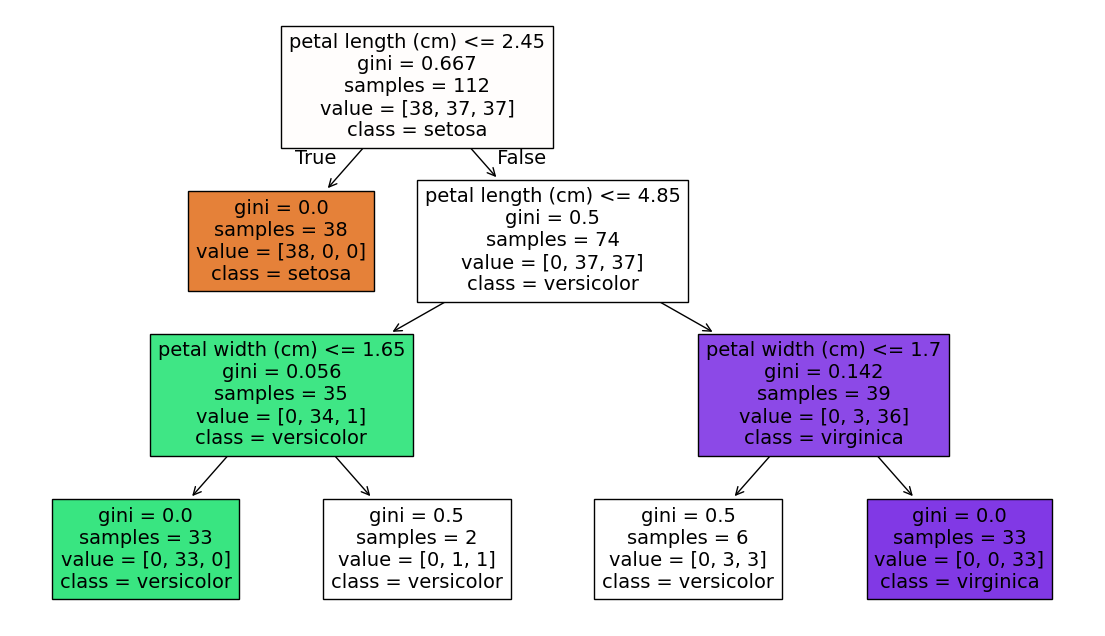

In [11]:
plt.figure(figsize=(14, 8))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

### Reflexión árbol

6. ¿Qué variable aparece en las primeras decisiones del árbol?
    > petal length
7. ¿Por qué los árboles son considerados modelos interpretables?
    > por que siguen un proceso de decisiones lógico
8. ¿Qué podría pasar si el árbol tiene demasiada profundidad?
    > podría tener overfiting y tardar en clasificar cada nodo

## 10. Modelo 3 — Naive Bayes

In [12]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

print("Accuracy Naive Bayes:", accuracy_score(y_test, nb_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, nb_predictions))
print()
print(classification_report(y_test, nb_predictions, target_names=iris.target_names))

Accuracy Naive Bayes: 0.9210526315789473

Matriz de confusión:
[[12  0  0]
 [ 0 12  1]
 [ 0  2 11]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



### Reflexión Naive Bayes

9. ¿Por qué Naive Bayes es considerado un modelo probabilístico?
    > Por que calcula la probabilidad de ocurrencia de datos independientes (o seo asume)
10. ¿Qué significa que asuma independencia entre variables?
    > Que asume que la existencia de un evento no afecta la probabilidad de que exista otro

## 11. Modelo 4 — SVM

In [13]:
svm = SVC(kernel="linear", probability=True, random_state=42)

svm.fit(X_train_scaled, y_train)

svm_predictions = svm.predict(X_test_scaled)

print("Accuracy SVM:", accuracy_score(y_test, svm_predictions))
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, svm_predictions))
print()
print(classification_report(y_test, svm_predictions, target_names=iris.target_names))

Accuracy SVM: 0.9736842105263158

Matriz de confusión:
[[12  0  0]
 [ 0 12  1]
 [ 0  0 13]]

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



### Reflexión SVM

11. ¿Qué significa que SVM busque una frontera con margen amplio?
    > Busca que las clases no sean equivalentes
12. ¿Por qué SVM puede beneficiarse del escalamiento?
    > Por la misma razón que kNN, usa distancias geometricas y unas mediciones pueden tener magnitude muy diferentes

# Parte 3 — Comparación de modelos

## 12. Tabla comparativa

In [14]:
models_results = pd.DataFrame({
    "Modelo": ["kNN", "Árbol de decisión", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, knn_predictions),
        accuracy_score(y_test, tree_predictions),
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, svm_predictions)
    ]
})

models_results

,Modelo,Accuracy
0,kNN,0.921053
1,Árbol de decisión,0.894737
2,Naive Bayes,0.921053
3,SVM,0.973684


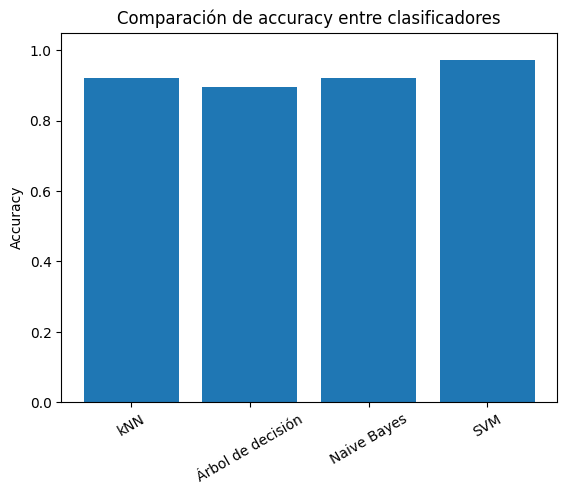

In [15]:
plt.bar(models_results["Modelo"], models_results["Accuracy"])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Comparación de accuracy entre clasificadores")
plt.xticks(rotation=30)
plt.show()

### Preguntas de comparación

13. ¿Qué modelo obtuvo mayor accuracy?
    > SVM
14. ¿Todos los modelos se equivocaron en los mismos casos?
    > No
15. ¿Elegirías el modelo con mayor accuracy automáticamente? ¿Por qué?
    > No, tendría que revisar si alguno tiene overfiting
16. ¿Cuál modelo te parece más interpretable?
    > Árboles
17. ¿Cuál modelo parece más dependiente del escalamiento?
    > kNN y SVM

# Parte 4 — Predicción con nuevos datos

In [16]:
new_samples = pd.DataFrame(
    [
        [5.1, 3.5, 1.4, 0.2],
        [6.0, 2.9, 4.5, 1.5],
        [6.7, 3.1, 5.6, 2.4]
    ],
    columns=iris.feature_names
)

new_samples

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,6.0,2.9,4.5,1.5
2,6.7,3.1,5.6,2.4


In [17]:
new_samples_scaled = scaler.transform(new_samples)

print("Predicciones kNN:", iris.target_names[knn.predict(new_samples_scaled)])
print("Predicciones Árbol:", iris.target_names[tree.predict(new_samples)])
print("Predicciones Naive Bayes:", iris.target_names[nb_model.predict(new_samples)])
print("Predicciones SVM:", iris.target_names[svm.predict(new_samples_scaled)])

Predicciones kNN: ['setosa' 'versicolor' 'virginica']
Predicciones Árbol: ['setosa' 'versicolor' 'virginica']
Predicciones Naive Bayes: ['setosa' 'versicolor' 'virginica']
Predicciones SVM: ['setosa' 'versicolor' 'virginica']


### Reflexión

18. ¿Todos los modelos predijeron lo mismo para los nuevos datos?
    > Sí
19. Si no coinciden, ¿cómo decidirías cuál predicción confiar?
    > De los que tengan el "factor común", el que tenga mayor accuracy, asegurando que no haya overfiting

# Parte 5 — Ejercicios autónomos con Pokémon

Ahora trabajarás con una base de datos de Pokémon.

## Instrucciones

1. Descarga una base de Pokémon de Kaggle.
2. Sube el archivo al entorno del notebook.
3. Renómbralo como `pokemon.csv`.
4. Ejecuta las celdas.
5. Completa los ejercicios.

## Sugerencia de objetivo

Puedes intentar clasificar:

- `Legendary` / no `Legendary`, si existe esa columna.
- Un tipo principal de Pokémon, por ejemplo `Type 1`, si quieres hacer multiclase.
- Otra variable categórica que tenga sentido en tu base.

Para empezar, este notebook asume que existe una columna llamada `Legendary`.

## 13. Cargar Pokémon

In [18]:
pokemon = pd.read_csv("pokemon.csv")

pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## 14. Explorar la base

In [19]:
pokemon.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


In [20]:
pokemon.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [21]:
pokemon.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')

## Ejercicio 1 — Elegir variables

Selecciona variables numéricas para clasificar Pokémon.

Sugerencia:

```python
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
target = "Legendary"
```

Ajusta los nombres si tu base usa otros nombres.

In [22]:
# Completa o ajusta según tu archivo

features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
target = "Legendary"

pokemon_model_data = pokemon[features + [target]].dropna()

X_pokemon = pokemon_model_data[features]
y_pokemon = pokemon_model_data[target]

X_pokemon.head()

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65


## Ejercicio 2 — Revisar clases

Antes de entrenar, revisa cuántos casos hay por clase.

In [23]:
# Completa esta celda

y_pokemon.value_counts()

Legendary
False    735
True      65
Name: count, dtype: int64

### Reflexión

20. ¿La base está balanceada o desbalanceada?
    > desbalanceada, hay muchos más NO legendarios
21. ¿Por qué esto puede afectar la evaluación?
    > es probable que se incline a pensar sobre NO legendarios, y haga overfiting para los legendarios

## Ejercicio 3 — Split train/test

Divide los datos en entrenamiento y prueba.

In [24]:
# Completa el split

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pokemon,
    y_pokemon,
    test_size=0.25,
    random_state=42,
    stratify=y_pokemon
)

print(X_train_p.shape)
print(X_test_p.shape)

(600, 6)
(200, 6)


## Ejercicio 4 — Escalamiento

Escala los datos para usar kNN y SVM.

In [25]:
# Completa el escalamiento

pokemon_scaler = StandardScaler()

X_train_p_scaled = pokemon_scaler.fit_transform(X_train_p)
X_test_p_scaled = pokemon_scaler.transform(X_test_p)

## Ejercicio 5 — Entrenar kNN

Entrena un clasificador kNN.

In [26]:
# Completa el modelo kNN

pokemon_knn = KNeighborsClassifier(n_neighbors=2)

pokemon_knn.fit(X_train_p_scaled, y_train_p)

pokemon_knn_predictions = pokemon_knn.predict(X_test_p_scaled)

print("Accuracy kNN:", accuracy_score(y_test_p, pokemon_knn_predictions))
print(confusion_matrix(y_test_p, pokemon_knn_predictions))
print(classification_report(y_test_p, pokemon_knn_predictions, zero_division=0))

Accuracy kNN: 0.935
[[181   3]
 [ 10   6]]
              precision    recall  f1-score   support

       False       0.95      0.98      0.97       184
        True       0.67      0.38      0.48        16

    accuracy                           0.94       200
   macro avg       0.81      0.68      0.72       200
weighted avg       0.93      0.94      0.93       200



## Ejercicio 6 — Entrenar árbol de decisión

In [27]:
# Completa el modelo de árbol

pokemon_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

pokemon_tree.fit(X_train_p_scaled, y_train_p)

pokemon_tree_predictions = pokemon_tree.predict(X_test_p_scaled)

print("Accuracy Árbol:", accuracy_score(y_test_p, pokemon_tree_predictions))
print(confusion_matrix(y_test_p, pokemon_tree_predictions))
print(classification_report(y_test_p, pokemon_tree_predictions, zero_division=0))

Accuracy Árbol: 0.92
[[181   3]
 [ 13   3]]
              precision    recall  f1-score   support

       False       0.93      0.98      0.96       184
        True       0.50      0.19      0.27        16

    accuracy                           0.92       200
   macro avg       0.72      0.59      0.62       200
weighted avg       0.90      0.92      0.90       200



## Ejercicio 7 — Entrenar Naive Bayes

In [28]:
# Completa Naive Bayes

pokemon_nb = GaussianNB()

pokemon_nb.fit(X_train_p_scaled, y_train_p)

pokemon_nb_predictions = pokemon_nb.predict(X_test_p_scaled)

print("Accuracy Naive Bayes:", accuracy_score(y_test_p, pokemon_nb_predictions))
print(confusion_matrix(y_test_p, pokemon_nb_predictions))
print(classification_report(y_test_p, pokemon_nb_predictions, zero_division=0))

Accuracy Naive Bayes: 0.91
[[170  14]
 [  4  12]]
              precision    recall  f1-score   support

       False       0.98      0.92      0.95       184
        True       0.46      0.75      0.57        16

    accuracy                           0.91       200
   macro avg       0.72      0.84      0.76       200
weighted avg       0.94      0.91      0.92       200



## Ejercicio 8 — Entrenar SVM

In [29]:
# Completa SVM

pokemon_svm = SVC(kernel="linear", probability=True, random_state=42)

pokemon_svm.fit(X_train_p_scaled, y_train_p)

pokemon_svm_predictions = pokemon_svm.predict(X_test_p_scaled)

print("Accuracy SVM:", accuracy_score(y_test_p, pokemon_svm_predictions))
print(confusion_matrix(y_test_p, pokemon_svm_predictions))
print(classification_report(y_test_p, pokemon_svm_predictions, zero_division=0))

Accuracy SVM: 0.93
[[179   5]
 [  9   7]]
              precision    recall  f1-score   support

       False       0.95      0.97      0.96       184
        True       0.58      0.44      0.50        16

    accuracy                           0.93       200
   macro avg       0.77      0.71      0.73       200
weighted avg       0.92      0.93      0.93       200



## Ejercicio 9 — Comparar modelos

Construye una tabla comparativa con los resultados.

In [30]:
# Completa la tabla

pokemon_results = pd.DataFrame({
    "Modelo": ["kNN", "Árbol", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test_p, pokemon_knn_predictions),
        accuracy_score(y_test_p, pokemon_tree_predictions),
        accuracy_score(y_test_p, pokemon_nb_predictions),
        accuracy_score(y_test_p, pokemon_svm_predictions)
    ]
})

pokemon_results

,Modelo,Accuracy
0,kNN,0.935
1,Árbol,0.920
2,Naive Bayes,0.910
3,SVM,0.930


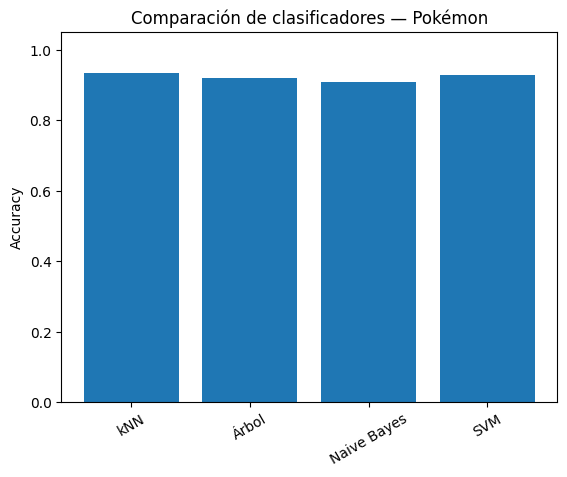

In [31]:
plt.bar(pokemon_results["Modelo"], pokemon_results["Accuracy"])
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Comparación de clasificadores — Pokémon")
plt.xticks(rotation=30)
plt.show()

## Reflexión final Pokémon

22. ¿Qué modelo tuvo mejor accuracy?
    > kNN
23. ¿Ese modelo también fue el más interpretable?
    > Sí
24. ¿La matriz de confusión muestra algún problema importante?
    > Todos están por debajo de 94%
25. Si la clase `Legendary` está desbalanceada, ¿accuracy es suficiente?
    > No
26. ¿Qué métrica adicional mirarías?
    > El ratio
27. ¿Qué modelo recomendarías y por qué?
    > kNN, ya que tengo entendido que para que sea `Legendary`, tiene que pasar cierto `treshhold` de stadísticas, y eso es lo que hace kNN
28. ¿Qué cambiarías para mejorar el desempeño?
    > Agregar más datos